# Ship Mode Performance Analysis

## Objective
This analysis evaluates the performance of different shipping modes used in the logistics network.

The goal is to compare shipping efficiency across modes such as Standard, First Class, Second Class, and Same Day delivery.

## Key Questions
- Which shipping mode handles the highest number of shipments?
- Which mode delivers shipments the fastest?
- Are faster shipping modes significantly more efficient?

In [1]:
# Import core libraries for data manipulation, numerical operations, and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/clean_shipping_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,lead_time,Profit_Margin
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,0.649231
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,0.653333
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,0.713467
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,0.694444
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,0.653333


## Dataset

The analysis uses the cleaned logistics dataset generated during the data cleaning stage of the project.

Source file:

data/processed/clean_shipping_data.csv

This dataset contains shipment-level information including:

- Ship Mode
- Factory Location
- Customer State / Region
- Shipment Date
- Delivery Date
- Shipping Lead Time

## Data Inspection

Before performing analysis, it is important to inspect the dataset structure.  
This step helps verify column names, data types, and detect any missing values that could affect the analysis.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

## Shipment Distribution by Ship Mode

This section analyzes how shipments are distributed across different shipping modes.

Understanding shipment distribution helps identify which shipping methods are most frequently used within the logistics network.

In [4]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

## Shipment Distribution by Ship Mode

This section analyzes how shipments are distributed across different shipping modes.

Understanding shipment distribution helps identify which shipping methods are most frequently used within the logistics network.

In [5]:
ship_mode_perf = df.groupby('Ship Mode').agg(
    Total_Shipments=('Ship Mode','count'),
    Avg_Lead_Time=('lead_time','mean'),
    Lead_Time_Std=('lead_time','std')
).reset_index()

ship_mode_perf

,Ship Mode,Total_Shipments,Avg_Lead_Time,Lead_Time_Std
0,First Class,1548,1338.275840,265.632140
1,Same Day,547,1333.442413,253.813374
2,Second Class,1979,1323.845376,261.813569
3,Standard Class,6120,1314.334641,262.400116


## Visualization of Shipping Performance

To better understand performance differences between shipping modes, we visualize the average lead time for each shipping method.

This helps identify which shipping modes deliver shipments faster and which ones may contribute to delays.

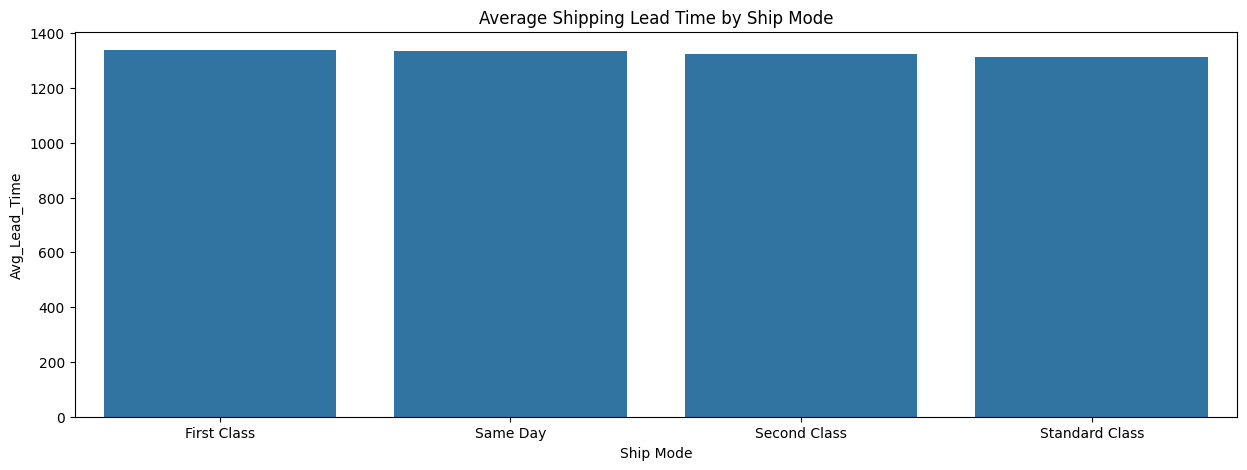

In [8]:
plt.figure(figsize=(15,5))

sns.barplot(
    data=ship_mode_perf,
    x='Ship Mode',
    y='Avg_Lead_Time'
)

plt.title("Average Shipping Lead Time by Ship Mode")

plt.show()

In [9]:
ship_mode_perf.to_csv("../data/processed/ship_mode_performance.csv",index=False)

## Key Insights

The analysis highlights differences in delivery performance across shipping modes.

Key observations may include:

- Certain shipping modes consistently provide faster delivery times.
- Some shipping modes handle a higher volume of shipments but may have longer delivery times.
- Lead time variability indicates the reliability of each shipping method.

Understanding these patterns helps logistics managers optimize shipping strategies and improve delivery efficiency.

## Business Recommendations

Based on the ship mode performance analysis, logistics teams can consider the following strategies:

- Prioritize faster shipping modes for time-sensitive deliveries.
- Monitor shipping modes with high lead time variability.
- Optimize resource allocation for high-volume shipping modes.

These insights support better decision-making in logistics planning and operational efficiency.